## Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.linalg import norm

rc('animation', html='jshtml')

plt.rc("font", family=["Helvetica", "Arial"]) # skifter skrifttype
plt.rc("axes", labelsize=18, titlesize=22)   # skriftstørrelse af `xlabel` og `ylabel`
plt.rc("xtick", labelsize=16, top=True, direction="in")  # skriftstørrelse af ticks og viser ticks øverst
plt.rc("ytick", labelsize=16, right=True, direction="in")
plt.rc("legend", fontsize=14)

M = np.array([1998559.0, 5.97, 0.642, 1898.0, 568.0, 86.8, 102.0, 0.013])*10**24 #kg # masse
d = np.array([1391684.0, 12756.0, 6792.0, 142984.0, 120536.0, 51118.0, 49528.0, 2390.0])*1000 #m #diameter
T = np.array([1e-12,365.2,687.0,4331.0,10747.0,30589.0,59800.0,90588.0])*24*60*60 #s #Omløbstid
r = np.array([0.0,149.6,227.9,778.6,1433.5,2872.5,4495.1,5870.0])*10**9 #m #Baneradius
ø = np.array([0.0,0.0,76.5,113.0,173.0,-106.0,-72.1,-134.0])*np.pi/180 #rad #Fase
a = [0,1,2,3,4,5,6,7] #index til loops
planeter_rækkefølge=["Solen","Jorden","Mars","Jupiter","Saturn","Uranus","Neptun","Pluto"]

G=6.67384*10**(-11) #m^3/(kg*s^2)

m_voy=722 #kg

# Solsystemet funktioner

In [2]:

def pos_planet(i,t):
    rx_planet=r[i]*np.cos(2*np.pi/T[i]*t+ø[i])
    ry_planet=r[i]*np.sin(2*np.pi/T[i]*t+ø[i])
    return [rx_planet, ry_planet]

def get_grav_acc_from_planet(i,t,rx,ry):
    return [(-M[i]*G)/abs(np.sqrt((rx-pos_planet(i,t)[0])**2+(ry-pos_planet(i,t)[1])**2))**3*(rx-pos_planet(i,t)[0]), 
           (-M[i]*G)/abs(np.sqrt((rx-pos_planet(i,t)[0])**2+(ry-pos_planet(i,t)[1])**2))**3*(ry-pos_planet(i,t)[1])]

# Delopgave a)

Text(0.5, 1.0, 'Voy 90% jordhastighed')

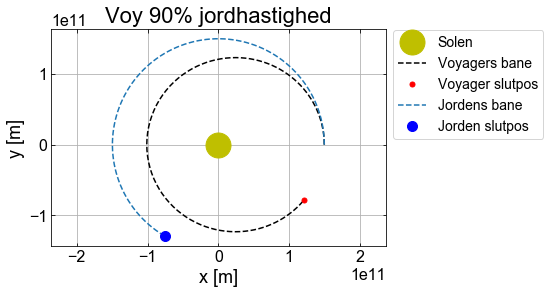

In [3]:
#Startbetingelser for voyager

rx0_voy = pos_planet(1,0)[0]+(1.2*d[1]/2)
ry0_voy = 0
vx0_voy = -r[1]*(2*np.pi/T[1])*np.sin((2*np.pi/T[1])*0+ø[1])*0.9 #afledte bestemt analytisk
vy0_voy = r[1]*(2*np.pi/T[1])*np.cos((2*np.pi/T[1])*0+ø[1])*0.9

y0 = [rx0_voy, ry0_voy, vx0_voy, vy0_voy] # hjælpevektor

t_span = [0,2/3*365.2*24*60*60]
t = np.linspace(0, 2/3*365.2*24*60*60, 200)

#differentialligning
def dydt(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    dvxdt=0
    dvydt=0
    for i in [0]:
        acc_x,acc_y = get_grav_acc_from_planet(i, t, rx, ry)
        dvxdt += acc_x
        dvydt += acc_y
    return [drxdt, drydt, dvxdt, dvydt]

res = solve_ivp(dydt, t_span, y0, t_eval = t, rtol=10**-9) #løsning

#plottes

plt.plot(0, 0, 'yo', ms="25",label="Solen")
plt.plot(res.y[0], res.y[1],color="k",linestyle="--", label="Voyagers bane") #bane voyager
plt.plot(res.y[0][-1], res.y[1][-1],"ro",ms=5,label="Voyager slutpos") #slutposition

plt.plot(pos_planet(1,t)[0],pos_planet(1,t)[1],label ="Jordens bane", ls="--")
plt.plot(pos_planet(1,t)[0][-1],pos_planet(1,t)[1][-1],"bo",ms=10,label="Jorden slutpos")

plt.axis("equal")
plt.legend(bbox_to_anchor=(1,0.46),loc="lower left",ncol=1)
plt.grid()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Voy 90% jordhastighed")

# Samme hastighed tjek

Det stemmer!


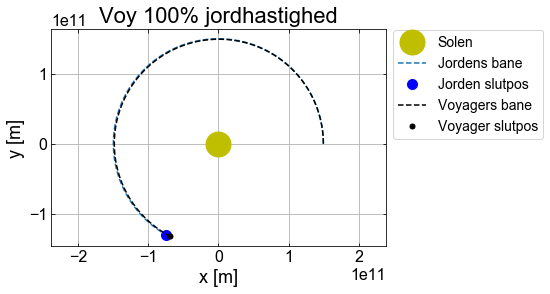

In [4]:
#copy pasted, slettet 0.9.

#Startbetingelser for voyager

rx0_voy = pos_planet(1,0)[0]+(1.2*d[1]/2)
ry0_voy = 0
vx0_voy = -r[1]*(2*np.pi/T[1])*np.sin((2*np.pi/T[1])*0+ø[1]) #afledte bestemt analytisk
vy0_voy = r[1]*(2*np.pi/T[1])*np.cos((2*np.pi/T[1])*0+ø[1])

y0 = [rx0_voy, ry0_voy, vx0_voy, vy0_voy] # hjælpevektor

t_span = [0,2/3*365.2*24*60*60]
t = np.linspace(0, 2/3*365.2*24*60*60, 200)

#differentialligning
def dydt(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    dvxdt=0
    dvydt=0
    for i in [0]:
        acc_x,acc_y = get_grav_acc_from_planet(i, t, rx, ry)
        dvxdt += acc_x
        dvydt += acc_y
    return [drxdt, drydt, dvxdt, dvydt]

res = solve_ivp(dydt, t_span, y0, t_eval = t, rtol=10**-9) #løsning

#plottes

plt.plot(0, 0, 'yo', ms="25",label="Solen")

plt.plot(pos_planet(1,t)[0],pos_planet(1,t)[1],label ="Jordens bane", ls="--")
plt.plot(pos_planet(1,t)[0][-1],pos_planet(1,t)[1][-1],"bo",ms=10,label="Jorden slutpos")

plt.plot(res.y[0], res.y[1],color="k",linestyle="--", label="Voyagers bane") #bane voyager
plt.plot(res.y[0][-1], res.y[1][-1],"ko",ms=5,label="Voyager slutpos") #slutposition

plt.axis("equal")
plt.legend(bbox_to_anchor=(1,0.46),loc="lower left",ncol=1)
plt.grid()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Voy 100% jordhastighed")

print("Det stemmer!")

# Deloopgave b)

Text(0.5, 1.0, 'Voy vy=15km/s ECI')

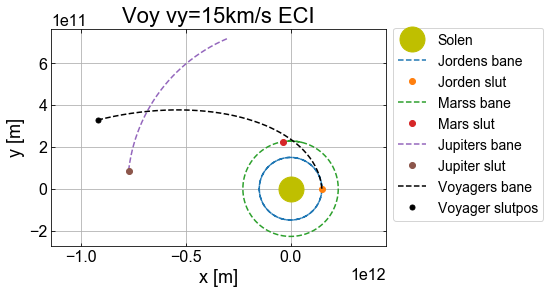

In [5]:
#Startbetingelser for voyager

rx0_voy = pos_planet(1,0)[0]+(1.2*d[1]/2)
ry0_voy = 0
vx0_voy = -r[1]*(2*np.pi/T[1])*np.sin((2*np.pi/T[1])*0+ø[1]) #afledte bestemt analytisk
vy0_voy = r[1]*(2*np.pi/T[1])*np.cos((2*np.pi/T[1])*0+ø[1])+15000

y0 = [rx0_voy, ry0_voy, vx0_voy, vy0_voy] # hjælpevektor

t_span = [0,2*365.2*24*60*60]
t = np.linspace(0, 2*365.2*24*60*60, 200)

#differentialligning
def dydt(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    dvxdt=0
    dvydt=0
    for i in [0,1]:
        acc_x,acc_y = get_grav_acc_from_planet(i, t, rx, ry)
        dvxdt += acc_x
        dvydt += acc_y
    return [drxdt, drydt, dvxdt, dvydt]

res = solve_ivp(dydt, t_span, y0, t_eval = t, rtol=10**-9) #løsning

#plottes

plt.plot(0, 0, 'yo', ms="25",label="Solen")

for i in range(1,len(a)-4):
    plt.plot(pos_planet(i,t)[0],pos_planet(i,t)[1],label=planeter_rækkefølge[i]+"s bane",linestyle="--")
    plt.plot(pos_planet(i,t)[0][-1],pos_planet(i,t)[1][-1],"o", label= planeter_rækkefølge[i]+" slut")

plt.plot(res.y[0], res.y[1],color="k",linestyle="--", label="Voyagers bane") #bane voyager
plt.plot(res.y[0][-1], res.y[1][-1],"ko",ms=5,label="Voyager slutpos") #slutposition

plt.axis("equal")
plt.legend(bbox_to_anchor=(1,0.085),loc="lower left",ncol=1)
plt.grid()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Voy vy=15km/s ECI")

# Delopgave c)

Text(0.5, 1.0, 'Voy undslipper ikke!')

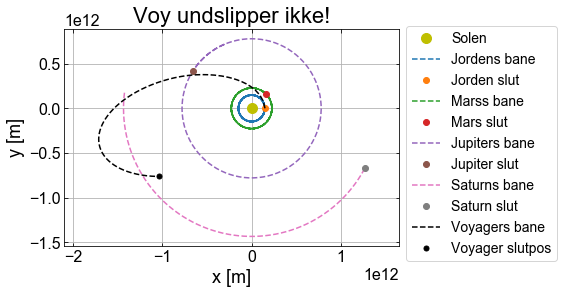

In [6]:
#Startbetingelser for voyager

rx0_voy = pos_planet(1,0)[0]+(1.2*d[1]/2)
ry0_voy = 0
vx0_voy = -r[1]*(2*np.pi/T[1])*np.sin((2*np.pi/T[1])*0+ø[1]) #afledte bestemt analytisk
vy0_voy = r[1]*(2*np.pi/T[1])*np.cos((2*np.pi/T[1])*0+ø[1])+15000

y0 = [rx0_voy, ry0_voy, vx0_voy, vy0_voy] # hjælpevektor

t_span = [0,13*365.2*24*60*60]
t = np.linspace(0, 13*365.2*24*60*60, 200)

#differentialligning
def dydt(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    dvxdt=0
    dvydt=0
    for i in a:
        acc_x,acc_y = get_grav_acc_from_planet(i, t, rx, ry)
        dvxdt += acc_x
        dvydt += acc_y
    return [drxdt, drydt, dvxdt, dvydt]

res = solve_ivp(dydt, t_span, y0, t_eval = t, rtol=10**-9)
#løsning

#plottes
plt.plot(0, 0, 'yo', ms="10",label="Solen")

for i in range(1,len(a)-3):
    plt.plot(pos_planet(i,t)[0],pos_planet(i,t)[1],label=planeter_rækkefølge[i]+"s bane",linestyle="--")
    plt.plot(pos_planet(i,t)[0][-1],pos_planet(i,t)[1][-1],"o", label= planeter_rækkefølge[i]+" slut")

plt.plot(res.y[0], res.y[1],color="k",linestyle="--", label="Voyagers bane") #bane voyager
plt.plot(res.y[0][-1], res.y[1][-1],"ko",ms=5,label="Voyager slutpos") #slutposition

plt.axis("equal")
plt.legend(bbox_to_anchor=(1,-0.1),loc="lower left",ncol=1)
plt.grid()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Voy undslipper ikke!")

# Animation spgs c)

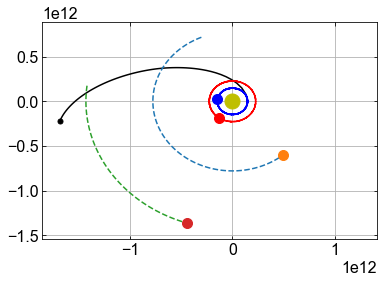

In [7]:
res = solve_ivp(dydt, t_span, y0, t_eval = t, rtol=10**-9)

fig, ax = plt.subplots(1,1)
ax.plot(0, 0, 'yo', ms="15")#solen
ax.grid()

t = np.linspace(0, 13*365.2*24*60*60, 200)


#voyagers bevægelser
voyager_line, = ax.plot(res.y[0], res.y[1], color="black",linestyle="-")#banebevægelsen
voyager, = ax.plot(res.y[0][0], res.y[1][0], color="black", marker="o", ls="", ms=5)

def jordenx(t):
    return r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
def jordeny(t):
    return r[1]*np.sin(2*np.pi/T[1]*t+ø[1])

def marsx(t):
    return r[2]*np.cos(2*np.pi/T[2]*t+ø[2])
def marsy(t):
    return r[2]*np.sin(2*np.pi/T[2]*t+ø[2])

def jupiterx(t):
    return r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
def jupitery(t):
    return r[3]*np.sin(2*np.pi/T[3]*t+ø[3])

def saturnx(t):
    return r[4]*np.cos(2*np.pi/T[4]*t+ø[4])
def saturny(t):
    return r[4]*np.sin(2*np.pi/T[4]*t+ø[4])

#Jordens bevægelse
jorden_line, = ax.plot(jordenx(t), jordeny(t), linestyle="--", color="blue")
jorden, = ax.plot(jordenx(t)[0], jordeny(t)[0], marker="o", ms="10", color="blue")

#Mars' bevægelse
mars_line, = ax.plot(marsx(t),marsy(t), linestyle="--", color="red")
mars, = ax.plot(marsx(t)[0],marsy(t)[0],marker="o", ms="10", color="red")

#Jupiters bevægelse
jupiter_line, = ax.plot(jupiterx(t),jupitery(t), linestyle="--")
jupiter, = ax.plot(jupiterx(t)[0],jupitery(t)[0],marker="o", ms="10")

#Saturns bevægelse
saturn_line, = ax.plot(saturnx(t),saturny(t), linestyle="--")
saturn, = ax.plot(saturnx(t)[0],saturny(t)[0],marker="o", ms="10")



#animation
def update(i):
       
    voyager_line.set_data(res.y[0][0:i+1], res.y[1][0:i+1])
    voyager.set_data(res.y[0][i], res.y[1][i])
    
    jorden_line.set_data(jordenx(t)[0:i+1], jordeny(t)[0:i+1])
    jorden.set_data(jordenx(t)[i], jordeny(t)[i])
    
    mars_line.set_data(marsx(t)[0:i+1], marsy(t)[0:i+1])
    mars.set_data(marsx(t)[i], marsy(t)[i])
    
    jupiter_line.set_data(jupiterx(t)[0:i+1], jupitery(t)[0:i+1])
    jupiter.set_data(jupiterx(t)[i], jupitery(t)[i])
    
    saturn_line.set_data(saturnx(t)[0:i+1], saturny(t)[0:i+1])
    saturn.set_data(saturnx(t)[i], saturny(t)[i])
    
    return voyager_line, voyager, jorden_line, jorden, mars_line, mars, jupiter_line, jupiter, saturn_line, saturn


anim = animation.FuncAnimation(fig,
                               update,
                               frames = 100,
                               interval=10,
                               blit=True)
anim

In [8]:
writer = animation.writers['pillow'](fps=50) # frames per second
anim.save('Voyager_2_opg_c.gif', writer=writer)


# Delopgave d)

Text(0.5, 1.0, 'Voy nærmer sig Jupiter')

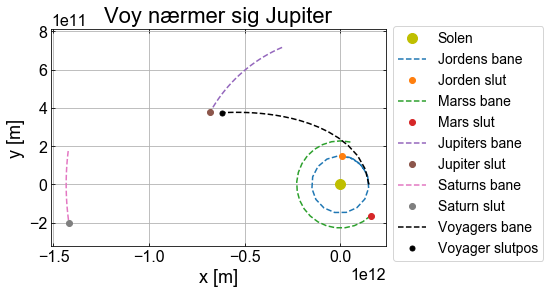

In [9]:
#Startbetingelser for voyager

rx0_voy = pos_planet(1,0)[0]+(1.2*d[1]/2)
ry0_voy = 0
vx0_voy = -r[1]*(2*np.pi/T[1])*np.sin((2*np.pi/T[1])*0+ø[1])
vy0_voy = r[1]*(2*np.pi/T[1])*np.cos((2*np.pi/T[1])*0+ø[1])+15000

y0 = [rx0_voy, ry0_voy, vx0_voy, vy0_voy] # hjælpevektor

t_span = [0,13*365.2*24*60*60]
t = np.linspace(0, 13*365.2*24*60*60, 200)

#differentialligning
def dydt(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    dvxdt=0
    dvydt=0
    for i in a:
        acc_x,acc_y = get_grav_acc_from_planet(i, t, rx, ry)
        dvxdt += acc_x
        dvydt += acc_y
    return [drxdt, drydt, dvxdt, dvydt]

#events-funktion
def track(t,y):
    rx = y[0]
    ry = y[1]
    rxjupiter = r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
    ryjupiter = r[3]*np.sin(2*np.pi/T[3]*t+ø[3])
    rvoy = np.array([rx,ry])
    rjupiter = np.array([rxjupiter, ryjupiter])
    dist = norm(rjupiter-rvoy)
    return dist-350*d[3]
track.terminal = True

res = solve_ivp(dydt, t_span, y0, t_eval = t, rtol=10**-9,events=track) #løsning

t_stop=res.t #nye t - går op til event (hvis event)


#plottes (med t_stop)
plt.plot(0, 0, 'yo', ms="10",label="Solen")

for i in range(1,len(a)-3):
    plt.plot(pos_planet(i,t_stop)[0],pos_planet(i,t_stop)[1],label=planeter_rækkefølge[i]+"s bane",linestyle="--")
    plt.plot(pos_planet(i,t_stop)[0][-1],pos_planet(i,t_stop)[1][-1],"o", label= planeter_rækkefølge[i]+" slut")

plt.plot(res.y[0], res.y[1],color="k",linestyle="--", label="Voyagers bane") #bane voyager
plt.plot(res.y[0][-1], res.y[1][-1],"ko",ms=5,label="Voyager slutpos") #slutposition

plt.axis("equal")
plt.legend(bbox_to_anchor=(1,-0.1),loc="lower left",ncol=1)
plt.grid()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Voy nærmer sig Jupiter")


# e)

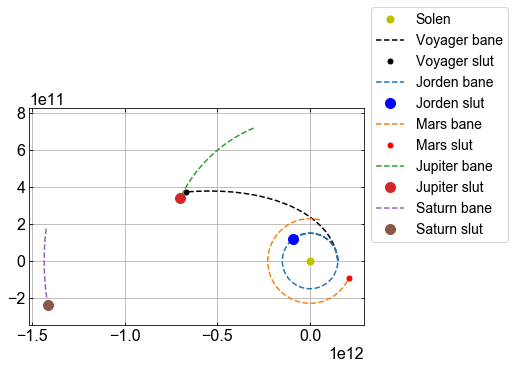

In [10]:
M_sol = M[0]
M_jord = M[1]
M_mars = M[2]
M_jupiter = M[3]
M_saturn = M[4]
M_uranus = M[5]
M_neptun = M[6]
M_pluto = M[7]

rx0_jord= r[1]*np.cos((2*np.pi)/(T[1])*0+ø[1])
ry0_jord= r[1]*np.sin((2*np.pi)/(T[1])*0+ø[1])

R_jord=d[1]/2

#Startbetingelser for voyager

rx0_voy = rx0_jord+(1.2*R_jord)
ry0_voy = 0
vx0_voy = (-r[1]*(2*np.pi/T[1])*np.sin((2*np.pi/T[1])*0+ø[1])) #afledte bestemt analytisk
vy0_voy = (r[1]*(2*np.pi/T[1])*np.cos((2*np.pi/T[1])*0+ø[1]))+15000

y0 = [rx0_voy, ry0_voy, vx0_voy, vy0_voy] # hjælpevektor

t_span = [0,2*365.2*24*60*60]
t_eval = np.linspace(0, 2*365.2*24*60*60, 100)



#differentialligning
def dydt(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    rxjord=r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
    ryjord=r[1]*np.sin(2*np.pi/T[1]*t+ø[1])
    rxmars=r[2]*np.cos(2*np.pi/T[2]*t+ø[2])
    rymars=r[2]*np.sin(2*np.pi/T[2]*t+ø[2])
    rxjupiter=r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
    ryjupiter=r[3]*np.sin(2*np.pi/T[3]*t+ø[3])
    rxsaturn=r[4]*np.cos(2*np.pi/T[4]*t+ø[4])
    rysaturn=r[4]*np.sin(2*np.pi/T[4]*t+ø[4])
    rxuranus=r[5]*np.cos(2*np.pi/T[5]*t+ø[5])
    ryuranus=r[5]*np.sin(2*np.pi/T[5]*t+ø[5])
    rxneptun=r[6]*np.cos(2*np.pi/T[6]*t+ø[6])
    ryneptun=r[6]*np.sin(2*np.pi/T[6]*t+ø[6])
    rxpluto=r[7]*np.cos(2*np.pi/T[7]*t+ø[7])
    rypluto=r[7]*np.sin(2*np.pi/T[7]*t+ø[7])
    d=np.sqrt(rx**2+ry**2)
    d_jord=np.sqrt((rx-rxjord)**2+(ry-ryjord)**2)
    d_mars=np.sqrt((rx-rxmars)**2+(ry-rymars)**2)
    d_jupiter=np.sqrt((rx-rxjupiter)**2+(ry-ryjupiter)**2)
    d_saturn=np.sqrt((rx-rxsaturn)**2+(ry-rysaturn)**2)
    d_uranus=np.sqrt((rx-rxuranus)**2+(ry-ryuranus)**2)
    d_neptun=np.sqrt((rx-rxneptun)**2+(ry-ryneptun)**2)
    d_pluto=np.sqrt((rx-rxpluto)**2+(ry-rypluto)**2)
    dvxdt = -(M_sol*G)/(abs(d**3))*rx+(-M_jord*G)/(abs(d_jord**3))*(rx-rxjord)+(-M_mars*G)/(abs(d_mars**3))*(rx-rxmars)+(-M_jupiter*G)/(abs(d_jupiter**3))*(rx-rxjupiter)+(-M_saturn*G)/(abs(d_saturn**3))*(rx-rxsaturn)+(-M_uranus*G)/(abs(d_uranus**3))*(rx-rxuranus)+(-M_neptun*G)/(abs(d_neptun**3))*(rx-rxneptun)+(-M_pluto*G)/(abs(d_pluto**3))*(rx-rxpluto)
    dvydt = -(M_sol*G)/(abs(d**3))*ry+(-M_jord*G)/(abs(d_jord**3))*(ry-ryjord)+(-M_mars*G)/(abs(d_mars**3))*(ry-rymars)+(-M_jupiter*G)/(abs(d_jupiter**3))*(ry-ryjupiter)+(-M_saturn*G)/(abs(d_saturn**3))*(ry-rysaturn)+(-M_uranus*G)/(abs(d_uranus**3))*(ry-ryuranus)+(-M_neptun*G)/(abs(d_neptun**3))*(ry-ryneptun)+(-M_pluto*G)/(abs(d_pluto**3))*(ry-rypluto)
    return [drxdt, drydt, dvxdt, dvydt]



#eventfunktion
def event(t,y):
    rx=y[0]
    ry=y[1]
    vx=y[2]
    vy=y[3]
    drxdt=vx
    drydt=vy
    
    rxjupiter = r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
    ryjupiter = r[3]*np.sin(2*np.pi/T[3]*t+ø[3])
    
    vxjupiter = -r[3]*np.sin(2*np.pi/T[3]*t+ø[3])*(2*np.pi/T[3])
    vyjupiter = r[3]*np.cos(2*np.pi/T[3]*t+ø[3])*(2*np.pi/T[3])
    
        
    rxtilde=rx-rxjupiter
    rytilde=ry-ryjupiter
    
    rtilde=np.array([rxtilde, rytilde])
    
    vxtilde=drxdt-vxjupiter
    vytilde=drydt-vyjupiter
    
    vtilde=np.array([vxtilde,vytilde])
    
    VII= np.dot(vtilde,rtilde)/np.dot(rtilde,rtilde)*rtilde
    
    fortegn=np.dot(vtilde, rtilde)
    return fortegn < 0
event.terminal = True

res = solve_ivp(dydt, t_span, y0, events=[event],t_eval = t_eval, rtol=10**-9)
#løsning

t_eval2 = np.linspace(0, res.t[-1], 100)
#plottes

plt.plot(0, 0, 'yo', ms="7",label="Solen")
plt.plot(res.y[0], res.y[1],color="k",linestyle="--", label="Voyager bane") #bane voyager
plt.plot(res.y[0][-1], res.y[1][-1],"ko",ms=5,label="Voyager slut") #slutposition


def jordenx(t):
    return r[1]*np.cos(2*np.pi/T[1]*t+ø[1])
def jordeny(t):
    return r[1]*np.sin(2*np.pi/T[1]*t+ø[1])

plt.plot(jordenx(t_eval2),jordeny(t_eval2),label="Jorden bane",linestyle="--")
plt.plot(jordenx(t_eval2)[-1],jordeny(t_eval2)[-1],"bo", ms=10,label="Jorden slut")

def marsx(t):
    return r[2]*np.cos(2*np.pi/T[2]*t+ø[2])
def marsy(t):
    return r[2]*np.sin(2*np.pi/T[2]*t+ø[2])

plt.plot(marsx(t_eval2),marsy(t_eval2),label="Mars bane",linestyle="--")
plt.plot(marsx(t_eval2)[-1],marsy(t_eval2)[-1],"ro", ms=5,label="Mars slut")

def jupiterx(t):
    return r[3]*np.cos(2*np.pi/T[3]*t+ø[3])
def jupitery(t):
    return r[3]*np.sin(2*np.pi/T[3]*t+ø[3])

plt.plot(jupiterx(t_eval2),jupitery(t_eval2),label="Jupiter bane",linestyle="--")
plt.plot(jupiterx(t_eval2)[-1],jupitery(t_eval2)[-1],"o", ms=10,label="Jupiter slut")

def saturnx(t):
    return r[4]*np.cos(2*np.pi/T[4]*t+ø[4])
def saturny(t):
    return r[4]*np.sin(2*np.pi/T[4]*t+ø[4])

plt.plot(saturnx(t_eval2),saturny(t_eval2),label="Saturn bane",linestyle="--")
plt.plot(saturnx(t_eval2)[-1],saturny(t_eval2)[-1],"o", ms=10,label="Saturn slut")


plt.axis("equal")
plt.legend(bbox_to_anchor=(1,0.35),loc="lower left",ncol=1)
plt.grid()